 # **Part III - Language Task**

In [1]:
!pip install contractions wordcloud gradio gensim --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.0 MB/s eta 0:00:00


##Import & Setup

In [2]:
import os, re, random, time, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import contractions
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import gensim.downloader as api
import gradio as gr

warnings.filterwarnings('ignore')
tf.get_logger().setLevel('ERROR')

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

nltk.download('wordnet',    quiet=True)
nltk.download('omw-1.4',   quiet=True)
nltk.download('stopwords', quiet=True)

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : '#f8f9fa',
    'axes.grid'        : True,
    'grid.alpha'       : 0.4,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 11
})

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


In [6]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/AI&ML/sarcastic_headlines.csv'
df = pd.read_csv(DATA_PATH)

print('Shape   :', df.shape)
print('Columns :', df.columns.tolist())
print('\nMissing values:')
print(df.isnull().sum())

df = df.dropna(subset=['headline', 'is_sarcastic']).reset_index(drop=True)
display(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape   : (28619, 2)
Columns : ['headline', 'is_sarcastic']

Missing values:
headline        0
is_sarcastic    0
dtype: int64


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


## Data Loading and Exploratory Analysis

Class Distribution:
  Not Sarcastic   :  14985  (52.4%)
  Sarcastic       :  13634  (47.6%)


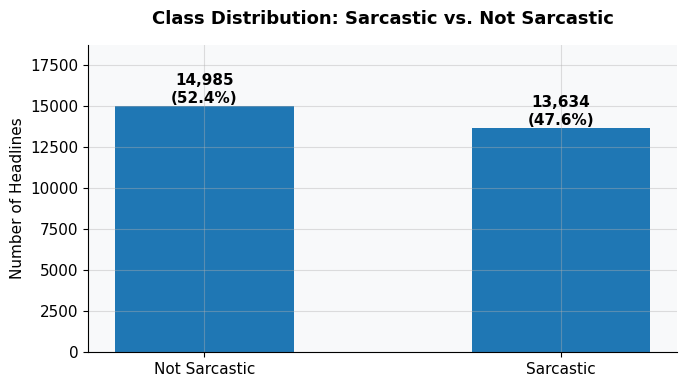

In [8]:
counts    = df['is_sarcastic'].value_counts().sort_index()
total     = len(df)
label_map = {0: 'Not Sarcastic', 1: 'Sarcastic'}

print('Class Distribution:')
for cls, cnt in counts.items():
    print(f'  {label_map[cls]:<16}: {cnt:>6}  ({cnt/total*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [label_map[0], label_map[1]],
    [counts[0], counts[1]],
    linewidth=1.5, width=0.5
)
for bar, (cls, cnt) in zip(bars, counts.items()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 40,
        f'{cnt:,}\n({cnt/total*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax.set_title('Class Distribution: Sarcastic vs. Not Sarcastic',
             fontsize=13, fontweight='bold', pad=15)
ax.set_ylabel('Number of Headlines')
ax.set_ylim(0, max(counts) * 1.25)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Text Preprocessing

In [9]:
_lemmatizer = WordNetLemmatizer()
_stopwords  = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()
    text = contractions.fix(text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = [t for t in text.split() if t not in _stopwords]
    tokens = [_lemmatizer.lemmatize(t) for t in tokens]
    result = ' '.join(tokens).strip()
    return result if result else 'unknown'


df['cleaned_text'] = df['headline'].apply(preprocess_text)

print('Before / After Preprocessing Examples:')
print('-' * 65)
for idx in df.sample(4, random_state=SEED).index:
    print(f'Original : {df.loc[idx, "headline"]}')
    print(f'Cleaned  : {df.loc[idx, "cleaned_text"]}')
    print()

orig_len    = df['headline'].str.split().str.len()
cleaned_len = df['cleaned_text'].str.split().str.len()
print(f'Average original length : {orig_len.mean():.1f} tokens')
print(f'Average cleaned length  : {cleaned_len.mean():.1f} tokens')

Before / After Preprocessing Examples:
-----------------------------------------------------------------
Original : states slow to shut down weak teacher education programs
Cleaned  : state slow shut weak teacher education program

Original : drone places fresh kill on steps of white house
Cleaned  : drone place fresh kill step white house

Original : report: majority of instances of people getting lives back on track occur immediately after visit to buffalo wild wings
Cleaned  : report majority instance people getting life back track occur immediately visit buffalo wild wing

Original : sole remaining lung filled with rich, satisfying flavor
Cleaned  : sole remaining lung filled rich satisfying flavor

Average original length : 10.0 tokens
Average cleaned length  : 7.1 tokens


## Data Visualisattion

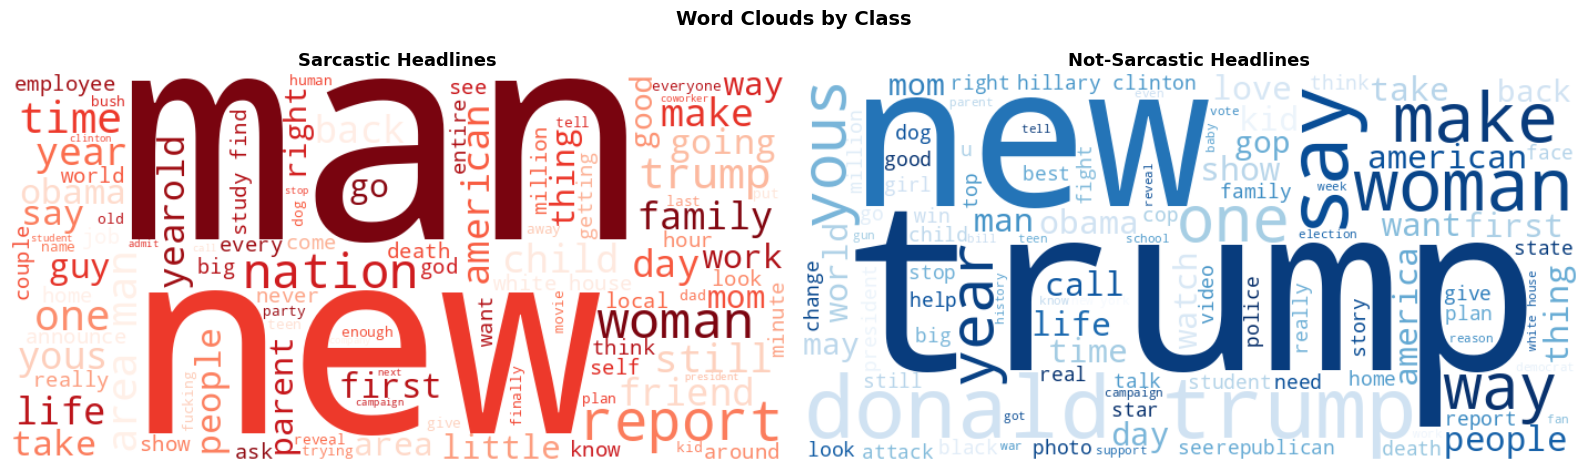

In [10]:
sarc_text     = ' '.join(df[df['is_sarcastic'] == 1]['cleaned_text'])
not_sarc_text = ' '.join(df[df['is_sarcastic'] == 0]['cleaned_text'])
all_text      = ' '.join(df['cleaned_text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Word Clouds by Class', fontsize=14, fontweight='bold')

for ax, text, title, cmap in zip(
    axes,
    [sarc_text, not_sarc_text],
    ['Sarcastic Headlines', 'Not-Sarcastic Headlines'],
    ['Reds', 'Blues']
):
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=cmap, max_words=100).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('word_clouds.png', dpi=150, bbox_inches='tight')
plt.show()

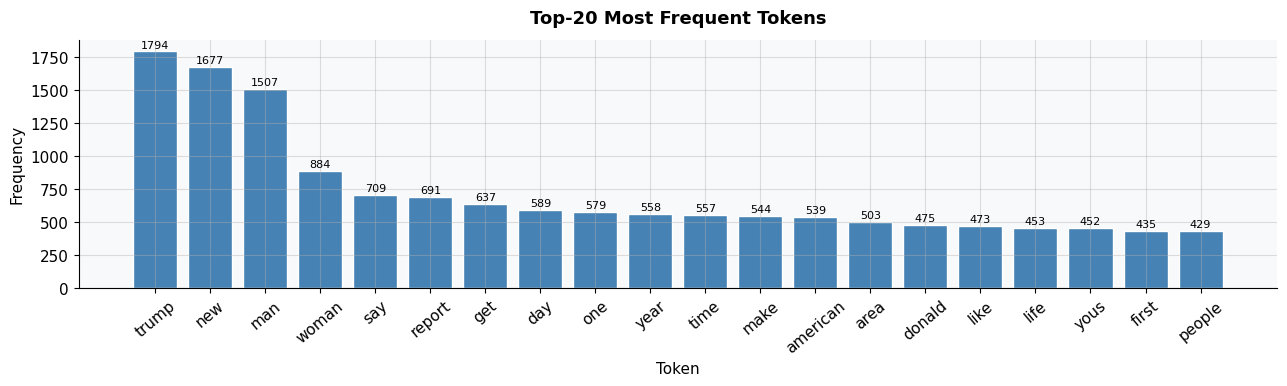

In [11]:
top20        = Counter(all_text.split()).most_common(20)
words, freqs = zip(*top20)

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(words, freqs, color='steelblue', edgecolor='white')
ax.set_title('Top-20 Most Frequent Tokens', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Token')
ax.set_ylabel('Frequency')
ax.tick_params(axis='x', rotation=40)
for bar, freq in zip(bars, freqs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            str(freq), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('top20_tokens.png', dpi=150, bbox_inches='tight')
plt.show()

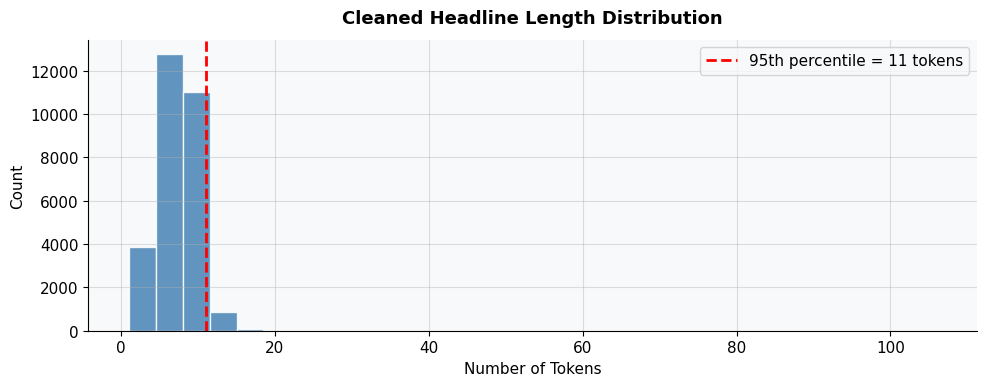

Padding length (95th percentile): 11 tokens


In [12]:
p95 = int(np.percentile(cleaned_len, 95))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cleaned_len, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(x=p95, color='red', linestyle='--', linewidth=2,
            label=f'95th percentile = {p95} tokens')
ax.set_title('Cleaned Headline Length Distribution', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Number of Tokens')
ax.set_ylabel('Count')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Padding length (95th percentile): {p95} tokens')

## Token and sequence padding

In [13]:
X = df['cleaned_text'].values
y = df['is_sarcastic'].values

# Stratified 80/20 split preserves class proportions
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

# Tokenizer fitted on training data only to prevent data leakage
# num_words=5000 limits vocabulary to the top 5000 most frequent words
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train_raw)
vocab_size = len(tokenizer.word_index)

X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

# 95th-percentile padding avoids excessively long sequences
max_len = int(np.percentile([len(s) for s in X_train_seq], 95))

X_train = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')
y_train = np.array(y_train)
y_test  = np.array(y_test)

results = {}

print(f'Vocabulary size  : {vocab_size:,}')
print(f'Max sequence len : {max_len}')
print(f'X_train shape    : {X_train.shape}')
print(f'X_test  shape    : {X_test.shape}')

Vocabulary size  : 22,570
Max sequence len : 11
X_train shape    : (22895, 11)
X_test  shape    : (5724, 11)


# Functions - for repeated Histroy, evaluation, sample inference

In [14]:
def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_loss', patience=5,
            restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-6, verbose=1
        )
    ]


def plot_training_history(history, model_name, color='steelblue'):
    epochs = range(1, len(history.history['accuracy']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} - Training History', fontsize=14, fontweight='bold')

    ax1.plot(epochs, history.history['accuracy'],
             color=color, lw=2, marker='o', markersize=4, label='Train')
    ax1.plot(epochs, history.history['val_accuracy'],
             color=color, lw=2, marker='s', markersize=4, linestyle='--', label='Validation')
    ax1.set_title('Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_ylim(0.40, 1.02)
    ax1.legend(loc='lower right')

    ax2.plot(epochs, history.history['loss'],
             color='tomato', lw=2, marker='o', markersize=4, label='Train')
    ax2.plot(epochs, history.history['val_loss'],
             color='tomato', lw=2, marker='s', markersize=4, linestyle='--', label='Validation')
    ax2.set_title('Loss', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right')

    plt.tight_layout()
    fname = model_name.replace(' ', '_').replace('+', 'plus').replace('-', '')
    plt.savefig(f'{fname}_history.png', dpi=150, bbox_inches='tight')
    plt.show()


def evaluate_model(model, X_test, y_test, model_name, history):
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred      = (y_pred_prob >= 0.5).astype(int)
    acc         = accuracy_score(y_test, y_pred)

    best_epoch = int(np.argmin(history.history['val_loss']))
    train_acc  = history.history['accuracy'][best_epoch]
    gap        = train_acc - acc

    print(f'\n{"="*50}')
    print(f'{model_name}')
    print(f'{"="*50}')
    print(f'Test Accuracy          : {acc:.4f}  ({acc*100:.2f}%)')
    print(f'Best Epoch             : {best_epoch + 1}')
    print(f'Train Accuracy at best : {train_acc:.4f}')
    print(f'Generalisation gap     : {gap:.4f}')

    cm     = confusion_matrix(y_test, y_pred)
    labels = ['Not Sarcastic', 'Sarcastic']
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(
        ax=ax, cmap='Blues', colorbar=True, values_format='d'
    )
    ax.set_title(f'{model_name} - Confusion Matrix', fontweight='bold', fontsize=12, pad=12)
    plt.xticks(rotation=15)
    plt.tight_layout()
    fname = model_name.replace(' ', '_').replace('+', 'plus').replace('-', '')
    plt.savefig(f'{fname}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=labels, digits=4))

    return {'accuracy': acc, 'y_pred': y_pred, 'y_pred_prob': y_pred_prob, 'cm': cm}


print('Helper functions defined.')

Helper functions defined.


## Model Building and Training

# Model 1: Simple RNN

In [23]:
VOCAB_CAP = min(vocab_size + 1, 5001)

rnn_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=VOCAB_CAP, output_dim=16),
    Dropout(0.3),
    SimpleRNN(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model_1_SimpleRNN')

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
rnn_model.summary()


Model: "Model_1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 11, 16)         │        80,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 11, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81,617 (318.82 KB)

 Trainable params: 81,617 (318.82 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
t0 = time.time()
rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=30, batch_size=64,
    validation_split=0.1,
    callbacks=get_callbacks(),
    verbose=1
)
rnn_time = (time.time() - t0) / 60
print(f'Training time: {rnn_time:.1f} min | Epochs: {len(rnn_history.history["accuracy"])}')

Epoch 1/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.6223 - loss: 0.6369 - val_accuracy: 0.7332 - val_loss: 0.5289 - learning_rate: 3.0000e-04
Epoch 2/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7795 - loss: 0.4673 - val_accuracy: 0.7908 - val_loss: 0.4556 - learning_rate: 3.0000e-04
Epoch 3/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8264 - loss: 0.3872 - val_accuracy: 0.8004 - val_loss: 0.4366 - learning_rate: 3.0000e-04
Epoch 4/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8567 - loss: 0.3343 - val_accuracy: 0.8017 - val_loss: 0.4355 - learning_rate: 3.0000e-04
Epoch 5/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8746 - loss: 0.3038 - val_accuracy: 0.8066 - val_loss: 0.4352 - learning_rate: 3.0000e-04
Epoch 6/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8858 - loss: 0.2778 - val_accuracy: 0.8100 - val_loss: 0.4515 - learning_rate: 3.0000e-04
Epoch 7/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accurac

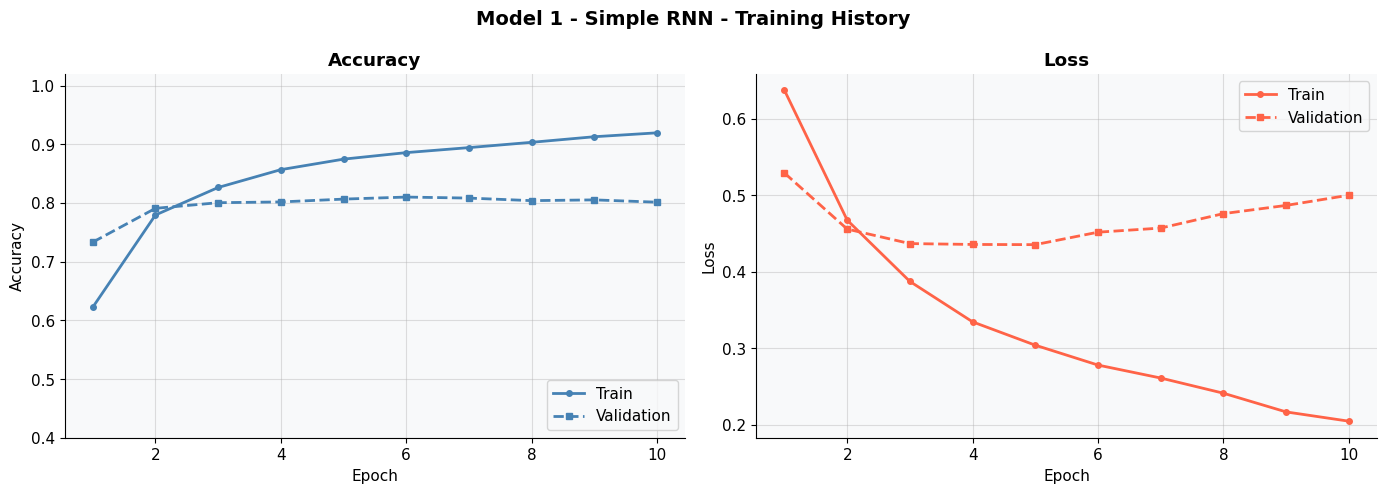

In [25]:
plot_training_history(rnn_history, 'Model 1 - Simple RNN')


Model 1 - Simple RNN
Test Accuracy          : 0.7897  (78.97%)
Best Epoch             : 5
Train Accuracy at best : 0.8746
Generalisation gap     : 0.0850


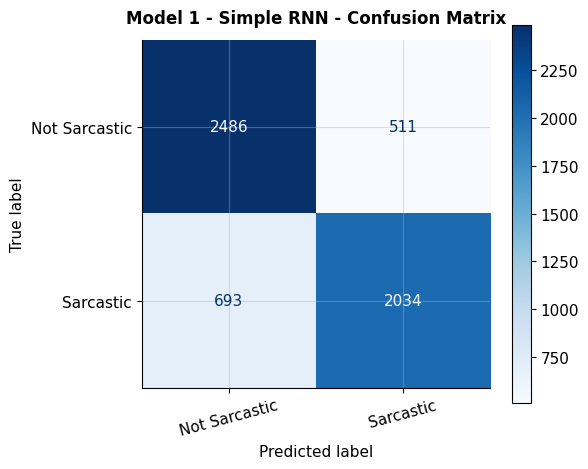


Classification Report:
               precision    recall  f1-score   support

Not Sarcastic     0.7820    0.8295    0.8051      2997
    Sarcastic     0.7992    0.7459    0.7716      2727

     accuracy                         0.7897      5724
    macro avg     0.7906    0.7877    0.7883      5724
 weighted avg     0.7902    0.7897    0.7891      5724



In [26]:
results['Simple RNN'] = evaluate_model(rnn_model, X_test, y_test, 'Model 1 - Simple RNN', rnn_history)

#Model 2: LSTM

In [27]:
lstm_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=VOCAB_CAP, output_dim=16),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model_2_LSTM')

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()


Model: "Model_2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 11, 16)         │        80,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 11, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 86,321 (337.19 KB)

 Trainable params: 86,321 (337.19 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
t0 = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=30, batch_size=64,
    validation_split=0.1,
    callbacks=get_callbacks(),
    verbose=1
)
lstm_time = (time.time() - t0) / 60
print(f'Training time: {lstm_time:.1f} min | Epochs: {len(lstm_history.history["accuracy"])}')

Epoch 1/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.6257 - loss: 0.6332 - val_accuracy: 0.7463 - val_loss: 0.5173 - learning_rate: 3.0000e-04
Epoch 2/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7870 - loss: 0.4586 - val_accuracy: 0.7917 - val_loss: 0.4573 - learning_rate: 3.0000e-04
Epoch 3/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8245 - loss: 0.3940 - val_accuracy: 0.7987 - val_loss: 0.4450 - learning_rate: 3.0000e-04
Epoch 4/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.8442 - loss: 0.3604 - val_accuracy: 0.7969 - val_loss: 0.4440 - learning_rate: 3.0000e-04
Epoch 5/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.8530 - loss: 0.3370 - val_accuracy: 0.7948 - val_loss: 0.4530 - learning_rate: 3.0000e-04
Epoch 6/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8615 - loss: 0.3224 - val_accuracy: 0.7921 - val_loss: 0.4606 - learning_rate: 3.0000e-04
Epoch 7/30
318/322 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accu

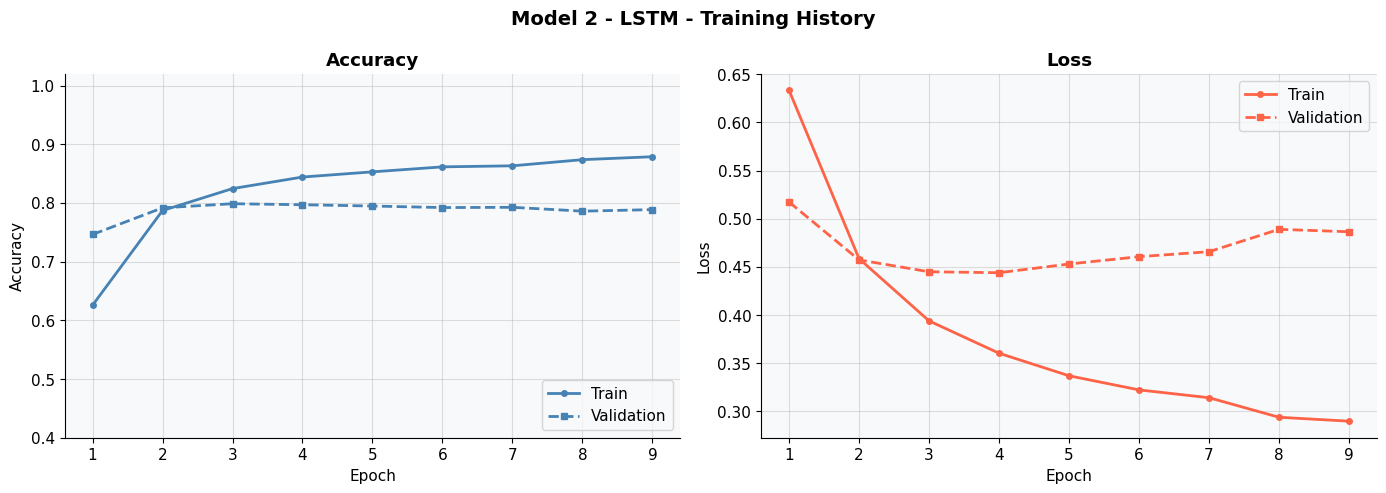

In [29]:
plot_training_history(lstm_history, 'Model 2 - LSTM')


Model 2 - LSTM
Test Accuracy          : 0.7802  (78.02%)
Best Epoch             : 4
Train Accuracy at best : 0.8442
Generalisation gap     : 0.0639


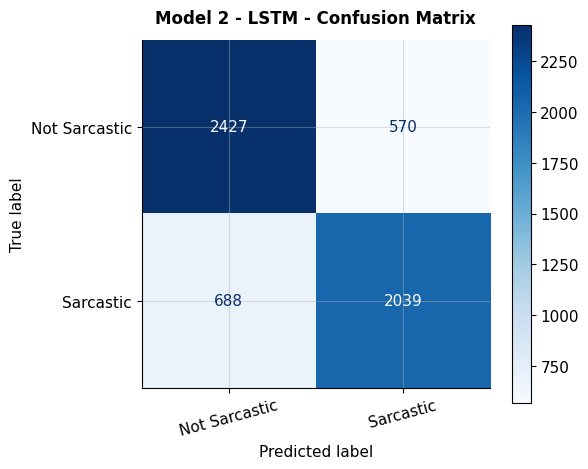


Classification Report:
               precision    recall  f1-score   support

Not Sarcastic     0.7791    0.8098    0.7942      2997
    Sarcastic     0.7815    0.7477    0.7642      2727

     accuracy                         0.7802      5724
    macro avg     0.7803    0.7788    0.7792      5724
 weighted avg     0.7803    0.7802    0.7799      5724



In [30]:
results['LSTM'] = evaluate_model(lstm_model, X_test, y_test, 'Model 2 - LSTM', lstm_history)

# Model 3: LSTM with GloVe Pretrained Embeddings

In [32]:
glove_model   = api.load('glove-twitter-100')
embedding_dim = 100
print(f'GloVe loaded - vocabulary: {len(glove_model.key_to_index):,} words')

embedding_matrix = np.zeros((vocab_size + 1, embedding_dim))
for word, i in tokenizer.word_index.items():
    if word in glove_model:
        embedding_matrix[i] = glove_model[word]

covered = sum(1 for w in tokenizer.word_index if w in glove_model)
print(f'GloVe coverage: {covered}/{vocab_size} ({covered/vocab_size*100:.1f}%)')

glove_lstm_model = Sequential([
    Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size + 1,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    Dropout(0.4),
    LSTM(64),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
], name='Model_3_LSTM_GloVe')

glove_lstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
glove_lstm_model.summary()

t0 = time.time()
glove_history = glove_lstm_model.fit(
    X_train, y_train,
    epochs=30, batch_size=64,
    validation_split=0.1,
    callbacks=get_callbacks(),
    verbose=1
)
glove_time = (time.time() - t0) / 60
print(f'Training time: {glove_time:.1f} min | Epochs: {len(glove_history.history["accuracy"])}')


[==================================================] 100.0% 387.1/387.1MB downloaded
GloVe loaded - vocabulary: 1,193,514 words
GloVe coverage: 19589/22570 (86.8%)


Model: "Model_3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 11, 100)        │     2,257,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 11, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,301,453 (8.78 MB)

 Trainable params: 44,353 (173.25 KB)

 Non-trainable params: 2,257,100 (8.61 MB)

Epoch 1/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 13s 24ms/step - accuracy: 0.6601 - loss: 0.6166 - val_accuracy: 0.7262 - val_loss: 0.5344 - learning_rate: 0.0010
Epoch 2/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.7141 - loss: 0.5591 - val_accuracy: 0.7576 - val_loss: 0.4854 - learning_rate: 0.0010
Epoch 3/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7395 - loss: 0.5262 - val_accuracy: 0.7712 - val_loss: 0.4642 - learning_rate: 0.0010
Epoch 4/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.7524 - loss: 0.5058 - val_accuracy: 0.7817 - val_loss: 0.4460 - learning_rate: 0.0010
Epoch 5/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7653 - loss: 0.4909 - val_accuracy: 0.7908 - val_loss: 0.4416 - learning_rate: 0.0010
Epoch 6/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7701 - loss: 0.4800 - val_accuracy: 0.7908 - val_loss: 0.4357 - learning_rate: 0.0010
Epoch 7/30
322/322 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.7778 - loss

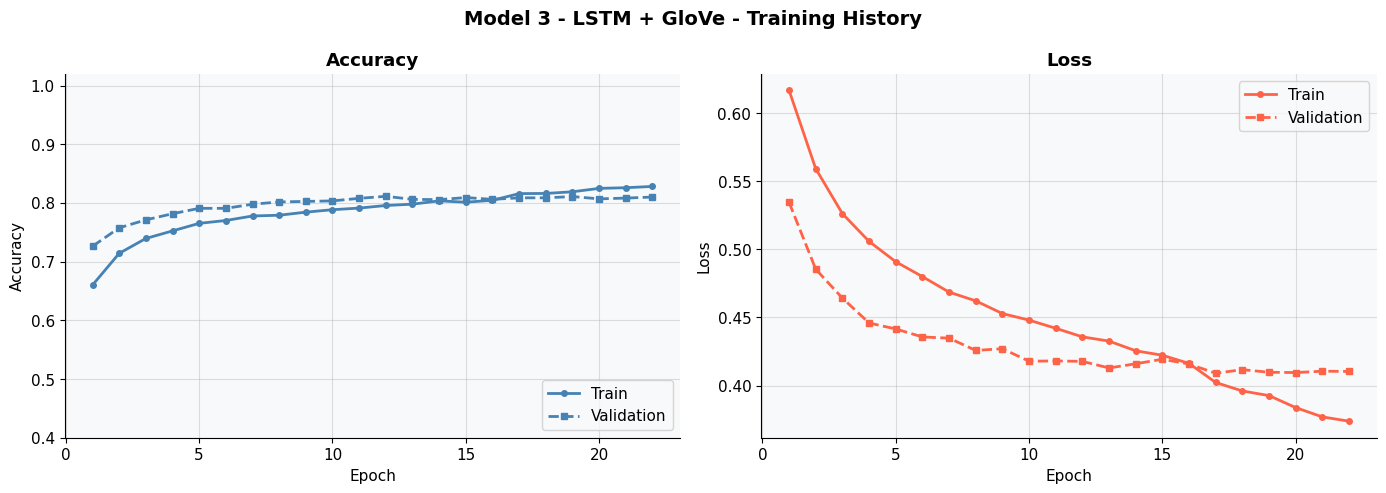

In [33]:
plot_training_history(glove_history, 'Model 3 - LSTM + GloVe')


Model 3 - LSTM + GloVe
Test Accuracy          : 0.7986  (79.86%)
Best Epoch             : 17
Train Accuracy at best : 0.8159
Generalisation gap     : 0.0174


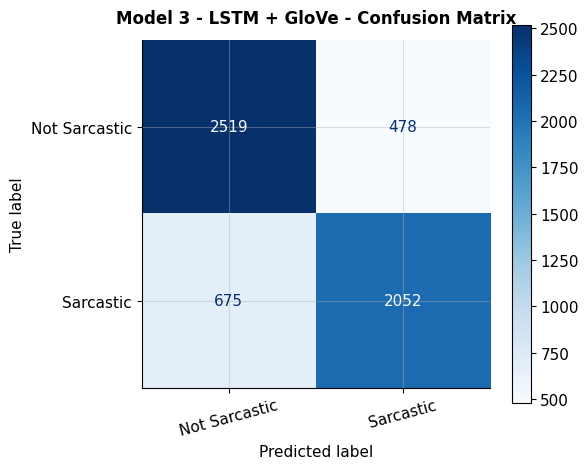


Classification Report:
               precision    recall  f1-score   support

Not Sarcastic     0.7887    0.8405    0.8138      2997
    Sarcastic     0.8111    0.7525    0.7807      2727

     accuracy                         0.7986      5724
    macro avg     0.7999    0.7965    0.7972      5724
 weighted avg     0.7993    0.7986    0.7980      5724



In [34]:
results['LSTM + GloVe'] = evaluate_model(glove_lstm_model, X_test, y_test, 'Model 3 - LSTM + GloVe', glove_history)

#Comparative Analysis

MODEL COMPARISON


,Model,Test Accuracy,Best Val Accuracy,Parameters,Epochs Run,Best Epoch,Train Time (min)
0,Simple RNN,0.7897,0.8100,"81,617",10,5,0.9
1,LSTM,0.7802,0.7987,"86,321",9,4,0.9
2,LSTM + GloVe,0.7986,0.8114,"2,301,453",22,17,2.6


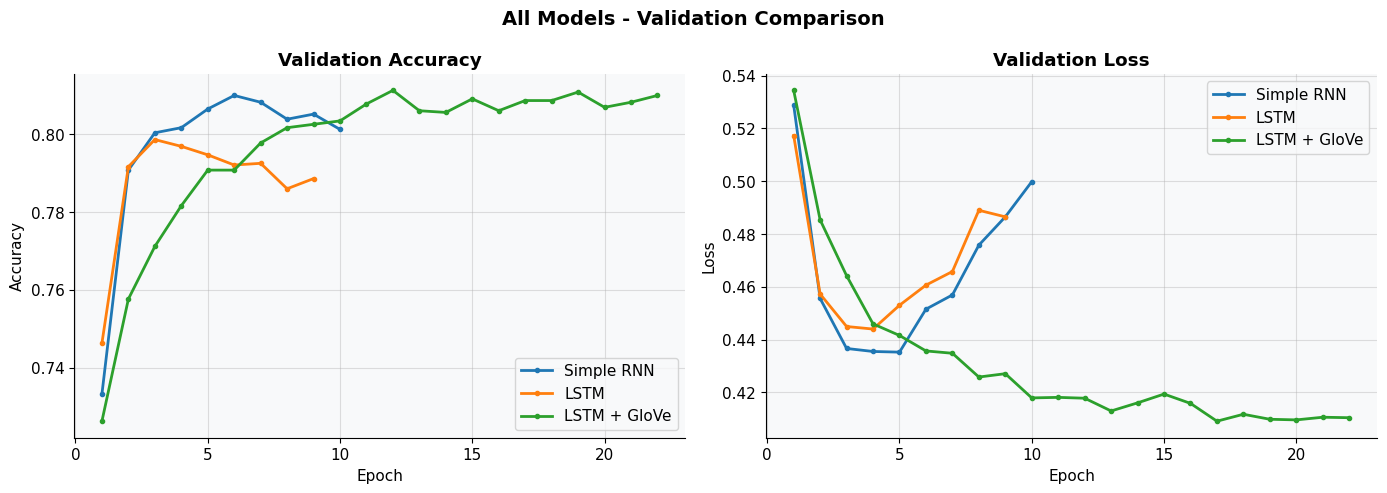

In [36]:
model_objects = {
    'Simple RNN'  : (rnn_model,       rnn_history,   rnn_time),
    'LSTM'        : (lstm_model,       lstm_history,  lstm_time),
    'LSTM + GloVe': (glove_lstm_model, glove_history, glove_time),
}
rows = []
for name, (model, history, t) in model_objects.items():
    best_ep = int(np.argmin(history.history['val_loss']))
    rows.append({
        'Model'            : name,
        'Test Accuracy'    : f"{results[name]['accuracy']:.4f}",
        'Best Val Accuracy': f"{max(history.history['val_accuracy']):.4f}",
        'Parameters'       : f"{model.count_params():,}",
        'Epochs Run'       : len(history.history['accuracy']),
        'Best Epoch'       : best_ep + 1,
        'Train Time (min)' : f"{t:.1f}",
    })

print('MODEL COMPARISON')
display(pd.DataFrame(rows))

# Validation accuracy and loss overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('All Models - Validation Comparison', fontsize=14, fontweight='bold')

for name, (_, history, _) in model_objects.items():
    ep = range(1, len(history.history['val_accuracy']) + 1)
    axes[0].plot(ep, history.history['val_accuracy'],
                 label=name, lw=2, marker='o', markersize=3)
    axes[1].plot(ep, history.history['val_loss'],
                 label=name, lw=2, marker='o', markersize=3)

axes[0].set_title('Validation Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Validation Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

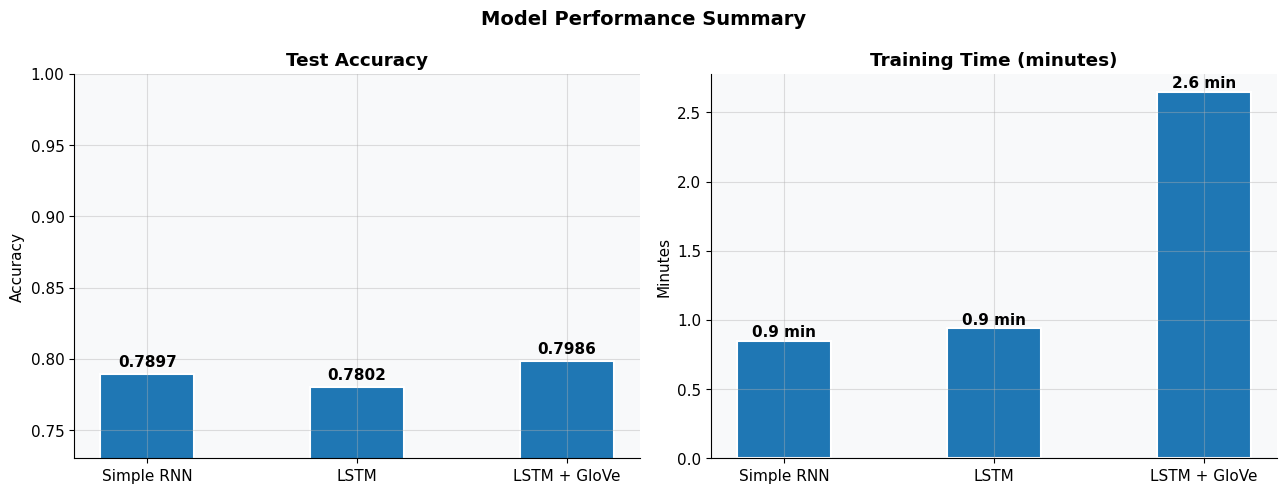

In [40]:
model_names = list(results.keys())
accuracies  = [results[n]['accuracy'] for n in model_names]
times       = [rnn_time, lstm_time, glove_time]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Performance Summary', fontsize=14, fontweight='bold')

bars = ax1.bar(model_names, accuracies,
               edgecolor='white', linewidth=1.5, width=0.45)
for bar, acc in zip(bars, accuracies):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
             f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_title('Test Accuracy', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(min(accuracies) - 0.05, 1.00)

bars2 = ax2.bar(model_names, times,
                edgecolor='white', linewidth=1.5, width=0.45)
for bar, t in zip(bars2, times):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{t:.1f} min', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_title('Training Time (minutes)', fontweight='bold')
ax2.set_ylabel('Minutes')

plt.tight_layout()
plt.savefig('model_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## Error Analysis

In [43]:
best_model_name = max(results, key=lambda k: results[k]['accuracy'])
model_map = {
    'Model 1 - Simple RNN'  : rnn_model,
    'Model 2 - LSTM'        : lstm_model,
    'Model 3 - LSTM + GloVe': glove_lstm_model
}
print(f'Error analysis on best model: {best_model_name}')

y_pred      = results[best_model_name]['y_pred']
y_pred_prob = results[best_model_name]['y_pred_prob']
lmap        = {0: 'Not Sarcastic', 1: 'Sarcastic'}

false_pos = [i for i in np.where(y_pred != y_test)[0] if y_pred[i] == 1 and y_test[i] == 0]
false_neg = [i for i in np.where(y_pred != y_test)[0] if y_pred[i] == 0 and y_test[i] == 1]

total_mis = len(false_pos) + len(false_neg)
print(f'Total misclassified : {total_mis} / {len(y_test)} ({total_mis/len(y_test)*100:.1f}%)')
print(f'False Positives     : {len(false_pos)}')
print(f'False Negatives     : {len(false_neg)}')

print('\n--- False Positives (predicted Sarcastic, actually Not) ---')
for i in false_pos[:3]:
    print(f'  Headline   : {X_test_raw[i]}')
    print(f'  True       : {lmap[y_test[i]]}  |  Predicted: {lmap[y_pred[i]]}')
    print(f'  Confidence : {y_pred_prob[i]:.4f}')
    print()

print('--- False Negatives (predicted Not Sarcastic, actually Sarcastic) ---')
for i in false_neg[:3]:
    print(f'  Headline   : {X_test_raw[i]}')
    print(f'  True       : {lmap[y_test[i]]}  |  Predicted: {lmap[y_pred[i]]}')
    print(f'  Confidence : {y_pred_prob[i]:.4f}')
    print()

print('--- Model Complexity vs. Performance ---')
print(f'{"Model":<20} {"Parameters":>12} {"Test Acc":>10} {"Train Time":>12}')
print('-' * 58)
for name, (model, history, t) in model_objects.items():
    print(f'{name:<20} {model.count_params():>12,} {results[name]["accuracy"]:>10.4f} {t:>10.1f}m')

Error analysis on best model: LSTM + GloVe
Total misclassified : 1153 / 5724 (20.1%)
False Positives     : 478
False Negatives     : 675

--- False Positives (predicted Sarcastic, actually Not) ---
  Headline   : mother special
  True       : Not Sarcastic  |  Predicted: Sarcastic
  Confidence : 0.6814

  Headline   : rex tillerson call report ouster laughable
  True       : Not Sarcastic  |  Predicted: Sarcastic
  Confidence : 0.7664

  Headline   : huckabee back denying abortion yearold raped stepfather
  True       : Not Sarcastic  |  Predicted: Sarcastic
  Confidence : 0.8474

--- False Negatives (predicted Not Sarcastic, actually Sarcastic) ---
  Headline   : democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
  True       : Sarcastic  |  Predicted: Not Sarcastic
  Confidence : 0.1897

  Headline   : prayer answered random series event cold uncaring universe
  True       : Sarcastic  |  Predicted: Not Sarcastic
  Confidence : 0.

## Gradio GUI - Real-Time Prediction

In [44]:
best_name  = max(results, key=lambda k: results[k]['accuracy'])
best_model = {
    'Model 1 - Simple RNN'  : rnn_model,
    'Model 2 - LSTM'        : lstm_model,
    'Model 3 - LSTM + GloVe': glove_lstm_model
}.get(best_name, glove_lstm_model)


def predict_sarcasm(headline):
    if not headline or not headline.strip():
        return 'Please enter a headline.'
    cleaned = preprocess_text(headline)
    seq     = tokenizer.texts_to_sequences([cleaned])
    padded  = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    prob    = best_model.predict(padded, verbose=0)[0][0]
    label   = 'Sarcastic' if prob >= 0.5 else 'Not Sarcastic'
    conf    = float(prob) if prob >= 0.5 else float(1 - prob)
    return f'Prediction  : {label}\nConfidence  : {conf*100:.1f}%\nModel       : {best_name}'


demo = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(
        label='Enter a News Headline',
        placeholder='e.g. Area man successfully avoids eye contact for entire subway ride',
        lines=2
    ),
    outputs=gr.Textbox(label='Prediction Result', lines=4),
    title='Sarcasm Detector - News Headlines',
    description=f'Powered by {best_name}. Trained on ~28,000 news headlines.',
    examples=[
        ['Scientists discover that vegetables are healthy'],
        ['Area man heroically manages to get out of bed before noon'],
        ['New study confirms people enjoy being happy'],
        ['Global leaders meet to discuss climate action over luxury dinner'],
    ],
    allow_flagging='never'
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a3ea1828c7fd59ecf7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
